In [ ]:
!pip install nbformat

Shape: (53940, 10)


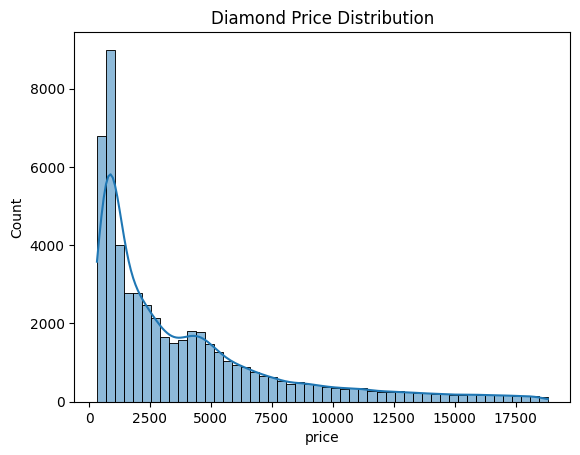

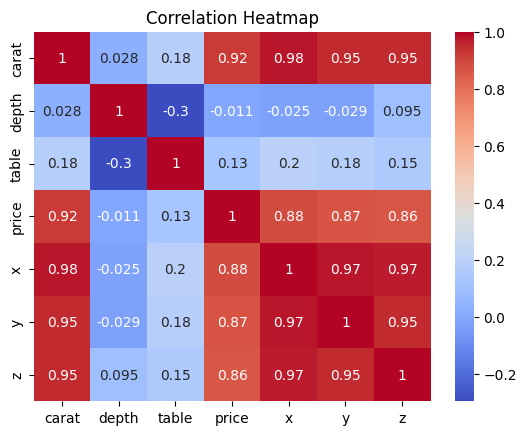

X shape: (53940, 23)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,809 (30.50 KB)

 Trainable params: 7,809 (30.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 22078944.0000 - mae: 2959.6641 - val_loss: 919251.5000 - val_mae: 602.3074
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2027930.7500 - mae: 692.4666 - val_loss: 724551.5625 - val_mae: 529.2191
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1310818.0000 - mae: 631.3698 - val_loss: 643050.9375 - val_mae: 482.7060
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1013231.1250 - mae: 586.7009 - val_loss: 597310.5000 - val_mae: 442.6122
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1166084.1250 - mae: 557.5840 - val_loss: 553642.3750 - val_mae: 423.5891
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1020162.2500 - mae: 541.4478 - val_loss: 521696.3750 - val_mae: 398.8518
Epoch 7/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1050097.6250 - mae: 530.4750 - val_loss: 503509.2500 - val_mae: 388.0041
Epoch 8/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss:

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE  : 330.1473388671875
RMSE : 618.8243389686608
R2   : 0.9759106636047363


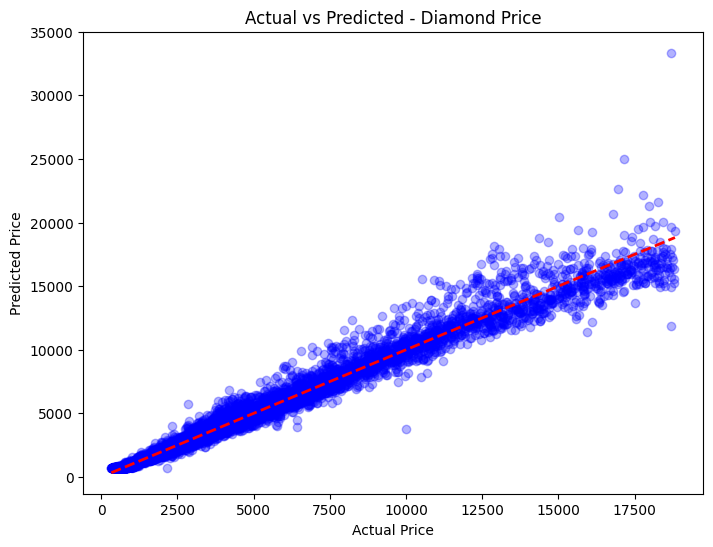

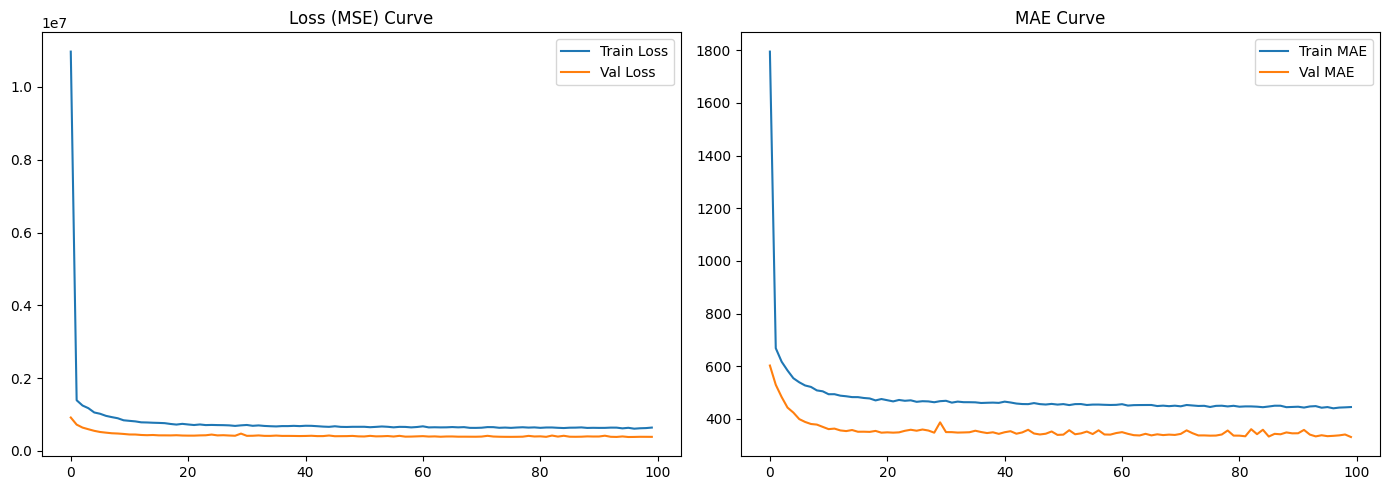

TypeError: unsupported operand type(s) for -: 'list' and 'int'

In [74]:
# ============================================================
#        ANN MINI PROJECT 2 - DIAMONDS PRICE PREDICTION
# ============================================================

# ── STEP 1: Import Libraries ──────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ── STEP 2: Load Dataset ──────────────────────────────────
df = sns.load_dataset('diamonds')
print("Shape:", df.shape)
df.head()

# ── STEP 3: EDA ───────────────────────────────────────────
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Diamond Price Distribution')
plt.show()

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ── STEP 4: Preprocessing ─────────────────────────────────
df = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

X = df.drop(columns=['price'])
y = df['price'].values

print("X shape:", X.shape)

# ── STEP 5: Train Test Split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── STEP 6: Feature Scaling ───────────────────────────────
scaler = StandardScaler()
X_train_trf = scaler.fit_transform(X_train)
X_test_trf  = scaler.transform(X_test)

# ── STEP 7: Build ANN Model ───────────────────────────────
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_trf.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear')   # Regression output
])

model.summary()

# ── STEP 8: Compile & Train ───────────────────────────────
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train_trf, y_train,
                    epochs=100,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

# ── STEP 9: Evaluate ──────────────────────────────────────
y_pred = model.predict(X_test_trf).flatten()

print("MAE  :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2   :", r2_score(y_test, y_pred))

# ── STEP 10: Actual vs Predicted Plot ────────────────────
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted - Diamond Price')
plt.show()

# ── STEP 11: Loss Curve ───────────────────────────────────
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE) Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Curve')
plt.legend()

plt.tight_layout()
plt.show()

# ── STEP 12: Predict New Diamond ─────────────────────────
# carat, depth, table, x, y, z + dummies (all 0 for base category)
new_diamond = np.array([[0.5, 61.5, 55, 5.0, 5.0, 3.0] + [0]*X_train.shape[1]-6])
# Better approach:
sample = X_test[:1]   # take one test sample as example
pred_price = model.predict(scaler.transform(scaler.inverse_transform(
             X_test_trf[:1])))
print("Predicted Price: $", round(pred_price[0][0], 2))

In [76]:
# ── STEP 12: Predict New Diamond ─────────────────────────
# carat, depth, table, x, y, z + dummies (all 0 for base category)
new_diamond = np.array([[0.5, 61.5, 55, 5.0, 5.0, 3.0] + [0]*(X_train.shape[1]-6)])
# Better approach:
sample = X_test[:1]   # take one test sample as example
pred_price = model.predict(scaler.transform(scaler.inverse_transform(
             X_test_trf[:1])))
print("Predicted Price: $", round(pred_price[0][0], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Price: $ 736.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
model.compile(loss='poisson')

YOUR PROBLEM
│
├── REGRESSION (predicting a number)
│   ├── No outliers?              → MSE
│   ├── Has outliers?             → MAE
│   ├── Some outliers?            → Huber Loss  ✅ Best choice
│   ├── Large range target?       → MSLE
│   └── Count data?               → Poisson Loss
│
├── BINARY CLASSIFICATION (2 classes)
│   ├── Balanced dataset?         → Binary Cross Entropy  ✅
│   ├── Imbalanced dataset?       → Focal Loss
│   └── SVM style?                → Hinge Loss
│
└── MULTI-CLASS CLASSIFICATION (3+ classes)
    ├── Labels are one-hot?       → Categorical Cross Entropy  ✅
    ├── Labels are integers?      → Sparse Categorical CE  ✅
    └── Generative model/VAE?     → KL Divergence



| Loss Function | Problem Type | Output Activation | Labels Format |
|---|---|---|---|
| MSE | Regression | linear | numbers |
| MAE | Regression | linear | numbers |
| Huber | Regression | linear | numbers |
| MSLE | Regression | linear | numbers |
| Binary CrossEntropy | Binary Classification | **sigmoid** | 0 or 1 |
| Hinge | Binary Classification | **tanh** | -1 or +1 |
| Categorical CrossEntropy | Multi-class | **softmax** | one-hot [0,1,0] |
| Sparse Categorical CE | Multi-class | **softmax** | integers 0,1,2 |
| KL Divergence | Generative Models | softmax | probabilities |
| Focal Loss | Imbalanced Classification | sigmoid | 0 or 1 |
| Poisson | Count Prediction | linear/softplus | counts |

## ✅ Simple Rule to Remember
```
Regression          →  MSE / Huber
2 Classes           →  Binary Cross Entropy
3+ Classes (one-hot)→  Categorical Cross Entropy
3+ Classes (integer)→  Sparse Categorical Cross Entropy
Imbalanced data     →  Focal Loss
Generative models   →  KL Divergence